In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os

import torch
import numpy as np
import matplotlib.pyplot as plt
import lightning
import lightning.pytorch.callbacks as pl_callbacks
from torch.utils.data import Dataset
import torchvision
import torchvision.transforms as transforms

import diffsci.models

In [4]:
# seed for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

## Colormaps

In [5]:
from pathlib import Path


def custom_spacing(min_val, max_val, N, alpha):
    """Power-law spaced points; matches the helper in the colormap script."""
    min_alpha = min_val ** alpha
    max_alpha = max_val ** alpha
    lin_space = torch.linspace(min_alpha, max_alpha, N)
    return lin_space ** (1 / alpha)


def load_fid_grid(path):
    """Load the FID-grid dict saved by ``scripts/testing/test-diffusion-mnist-colormap.py``."""
    return torch.load(path, map_location="cpu", weights_only=False)


def plot_fid_colormap(data, title=None, figpath=None, plot_sigma=False,
                      noisescheduler=None, cmap='viridis', fontsize=12,
                      annot_fmt='{:.2f}'):
    """Plot the FID colormap from the dict produced by the colormap script.

    Parameters
    ----------
    data : dict | str | Path
        Either the dict loaded from the ``.pt`` file or a path to it. Must
        contain ``fid_grid`` (``ngrid x ngrid`` tensor with NaN on the diagonal
        and below), ``fid_ode``, ``initial_time``, ``tmin``, ``ngrid``, ``alpha``,
        and optionally ``gamma`` and ``S_values``.
    plot_sigma : bool
        If True, label axes with sigma(S) values instead of S; requires a
        ``noisescheduler`` argument.
    """
    if isinstance(data, (str, Path)):
        data = load_fid_grid(data)

    fid_grid = data['fid_grid'].clone().float()
    fid_ode = float(data['fid_ode'])
    initial_time = float(data['initial_time'])
    tmin = float(data['tmin'])
    ngrid = int(data['ngrid'])
    alpha = float(data['alpha'])
    gamma = data.get('gamma', None)

    # Fill diagonal NaNs with the ODE FID (S_min == S_max => no SDE noise window).
    for i in range(ngrid):
        if torch.isnan(fid_grid[i, i]):
            fid_grid[i, i] = fid_ode
        else:
            print(f'for i={i}, fid={fid_grid[i, i]:.4f}')
            raise ValueError('FID should be NaN on the diagonal')

    fid_plot = torch.flip(fid_grid, dims=(0,))

    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    im = ax.imshow(fid_plot.numpy(), cmap=cmap)

    ax.set_xticks(np.arange(ngrid))
    ax.set_yticks(np.arange(ngrid))

    # Derive axis values directly from the saved interval_grid (works for
    # custom_spacing-built grids and manually-defined ones alike). After the
    # flat list is reshape(ngrid, ngrid), entry [i, j] = (S_min[i], S_max[j]).
    interval_grid = data.get('interval_grid', None)
    if interval_grid is not None:
        s_min_vals = [float(interval_grid[i * ngrid][0]) for i in range(ngrid)]
        s_max_vals = [float(interval_grid[j][1]) for j in range(ngrid)]
    else:
        # Backward compat: fall back to S_values / custom_spacing.
        s_values = data.get('S_values', None)
        if s_values is None or (torch.is_tensor(s_values) and s_values.numel() == 0):
            s_values = custom_spacing(tmin, initial_time, ngrid, alpha=alpha)
        s_values = [float(v) for v in torch.as_tensor(s_values)]
        s_min_vals = s_values
        s_max_vals = s_values

    if plot_sigma:
        if noisescheduler is None:
            raise ValueError('noisescheduler is required when plot_sigma=True')
        s_min_vals = [noisescheduler.scheduler_fns.noise_fn(torch.tensor(t)).item()
                      for t in s_min_vals]
        s_max_vals = [noisescheduler.scheduler_fns.noise_fn(torch.tensor(t)).item()
                      for t in s_max_vals]

    x_labels = [f'{v:.3f}' for v in s_max_vals]
    # Rows were flipped (np.flip on dim 0) so the y-axis labels are reversed.
    y_labels = [f'{v:.3f}' for v in s_min_vals[::-1]]
    ax.set_xticklabels(x_labels)
    ax.set_yticklabels(y_labels)

    if plot_sigma:
        ax.set_xlabel(r'$\sigma(S_{max})$', fontsize=fontsize)
        ax.set_ylabel(r'$\sigma(S_{min})$', fontsize=fontsize)
    else:
        ax.set_xlabel(r'$S_{max}$', fontsize=fontsize)
        ax.set_ylabel(r'$S_{min}$', fontsize=fontsize)

    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

    for i in range(ngrid):
        for j in range(ngrid):
            val = fid_plot[i, j].item()
            if np.isnan(val):
                continue
            ax.text(j, i, annot_fmt.format(val),
                    ha='center', va='center', color='w', fontsize=13)

    cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('FID', fontsize=fontsize)

    if title is None:
        title_str = f'FID colormap'
        if gamma is not None:
            title_str += rf', $\gamma$={gamma}'
    else:
        title_str = title
    ax.set_title(title_str, fontsize=fontsize + 6, pad=20)
    fig.tight_layout()

    if figpath is not None:
        figpath = Path(figpath)
        figpath.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(figpath)
    plt.show()

    return fid_plot

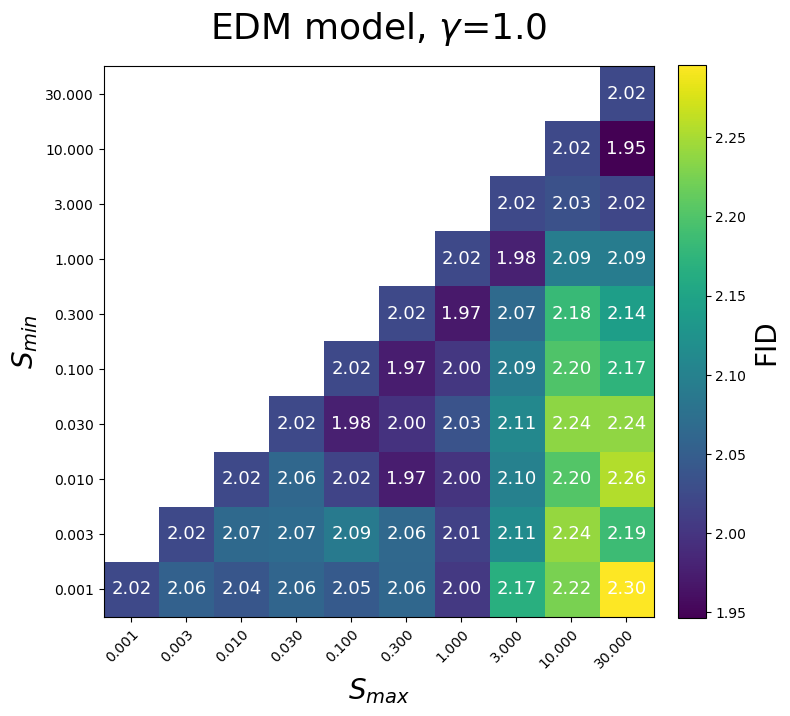

In [6]:
fid_grid_name = (
    "/home/ubuntu/repos/DiffSci/notebooks/exploratory/bps/karras_cifar10_edm_colormaps/fid_colormap_50000_samples_seed_45_nvidia-edm-nsteps=1000-manual_grid-parallel_g=1.0/fid_grid-g=1.0.pt"
)
data = load_fid_grid(fid_grid_name)
gamma = 1.0
fid_grid_path = Path(fid_grid_name)
fig_path = fid_grid_path.parent / f'colormap-g={gamma}.png'
fontsize = 20

if 'epoch=9' in fid_grid_name:
    title = r'Model 1, $\gamma$={}'.format(gamma)
elif 'epoch=19' in fid_grid_name:
    title = r'Model 2, $\gamma$={}'.format(gamma)
elif 'epoch=39' in fid_grid_name:
    title = r'Model 3, $\gamma$={}'.format(gamma)
elif 'vp' in fid_grid_name:
    title = r'VP model, $\gamma$={}'.format(gamma)
elif 'edm' in fid_grid_name:
    title = r'EDM model, $\gamma$={}'.format(gamma)
else:
    raise ValueError(f'Unknown epoch: {fid_grid_name}')

_ = plot_fid_colormap(data, title=title, figpath=fig_path, fontsize=fontsize)

## $\text{FID}\times\gamma$ curves

In [7]:
import re
from pathlib import Path

def parse_fid_file(path):
    text = Path(path).read_text()

    # Parse: FID Score (ODE): <value>
    ode_match = re.search(r"FID\s+Score\s*\(ODE\)\s*:\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)", text)
    ode_fid = float(ode_match.group(1)) if ode_match else np.nan

    # Parse: FID Score (SDE, gamma=<gamma>): <value>
    sde_matches = re.findall(
        r"FID\s+Score\s*\(SDE,\s*(?:gamma|γ)\s*=\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)\)\s*:\s*([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)",
        text,
    )

    gammas = np.array([float(g) for g, _ in sde_matches], dtype=float)
    sde_fids = np.array([float(v) for _, v in sde_matches], dtype=float)

    # Keep curves sorted by gamma for plotting
    if len(gammas) > 0:
        order = np.argsort(gammas)
        gammas = gammas[order]
        sde_fids = sde_fids[order]

    return ode_fid, gammas, sde_fids


def extract_epoch_from_path(path):
    m = re.search(r"epoch=(\d+)", path)
    return int(m.group(1)) if m else -1

In [11]:
# get fids
mode = "cifar10"

if mode == "perturbed_prior":
    fid_40_path = "/home/ubuntu/repos/DiffSci/savedmodels/production/20260318-bps-mnist-128ch/stats/fid_results_10000_samples_seed_45_nsteps=500-max_scale=40-epoch=39/fid_scores.txt"
    fid_80_path = "/home/ubuntu/repos/DiffSci/savedmodels/production/20260318-bps-mnist-128ch/stats/fid_results_10000_samples_seed_45_nsteps=500-max_scale=80-epoch=39/fid_scores.txt"
    fid_160_path = "/home/ubuntu/repos/DiffSci/savedmodels/production/20260318-bps-mnist-128ch/stats/fid_results_10000_samples_seed_45_nsteps=500-max_scale=160-epoch=39/fid_scores.txt"
    fid_paths = [fid_40_path, fid_80_path, fid_160_path]
    labels = ["$\sigma=40$", "$\sigma=80$ (default)", "$\sigma=160$"]

elif mode == "default_prior":
    fid09_path = "/home/ubuntu/repos/DiffSci/savedmodels/production/20260318-bps-mnist-128ch/stats/fid_results_50000_samples_seed_42_nsteps=500-epoch=9/fid_scores.txt"
    fid19_path = "/home/ubuntu/repos/DiffSci/savedmodels/production/20260318-bps-mnist-128ch/stats/fid_results_50000_samples_seed_42_nsteps=500-epoch=19/fid_scores.txt"
    fid39_path = "/home/ubuntu/repos/DiffSci/savedmodels/production/20260318-bps-mnist-128ch/stats/fid_results_50000_samples_seed_42_nsteps=500-epoch=39/fid_scores.txt"
    fid_paths = [fid09_path, fid19_path, fid39_path]
    labels = ['Model 1', 'Model 2', 'Model 3']

elif mode == "cifar10":
    fid_vp256_path = "/home/ubuntu/repos/DiffSci/notebooks/exploratory/bps/cifar10_fid_results-seed=42-vp-nsteps=256-nsamples=50000/fid_scores.txt"
    fid_edm256_path = "/home/ubuntu/repos/DiffSci/notebooks/exploratory/bps/cifar10_fid_results-seed=42-nsteps=256-nsamples=50000/fid_scores.txt"
    fid_vp1000_path = "/home/ubuntu/repos/DiffSci/notebooks/exploratory/bps/cifar10_fid_results-seed=42-vp-nsteps=1000-nsamples=50000/fid_scores.txt"
    fid_edm1000_path = "/home/ubuntu/repos/DiffSci/notebooks/exploratory/bps/cifar10_fid_results-seed=42-nsteps=1000-nsamples=50000/fid_scores.txt"
    fid_paths = [fid_vp256_path, fid_edm256_path, fid_vp1000_path, fid_edm1000_path]
    labels = ["VP (256 steps)", "EDM (256 steps)", "VP (1000 steps)", "EDM (1000 steps)"]


<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_3461448/2304995313.py:9: SyntaxWarning: invalid escape sequence '\s'
  labels = ["$\sigma=40$", "$\sigma=80$ (default)", "$\sigma=160$"]
/tmp/ipykernel_3461448/2304995313.py:9: SyntaxWarning: invalid escape sequence '\s'
  labels = ["$\sigma=40$", "$\sigma=80$ (default)", "$\sigma=160$"]
/tmp/ipykernel_3461448/2304995313.py:9: SyntaxWarning: invalid escape sequence '\s'
  labels = ["$\sigma=40$", "$\sigma=80$ (default)", "$\sigma=160$"]


In [12]:

import matplotlib.colors as mcolors
base_colors = ['blue', 'green', 'red']
alpha_light = 0.65
alpha_dark = 0.95

colors = [
    (*mcolors.to_rgb(c), alpha_light) for c in base_colors
] + [
    (*mcolors.to_rgb(c), alpha_dark) for c in base_colors
]

## FID gamma curves

<>:43: SyntaxWarning: invalid escape sequence '\g'
<>:43: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_3461448/3233956207.py:43: SyntaxWarning: invalid escape sequence '\g'
  plt.xlabel("$\gamma$", fontsize=14)


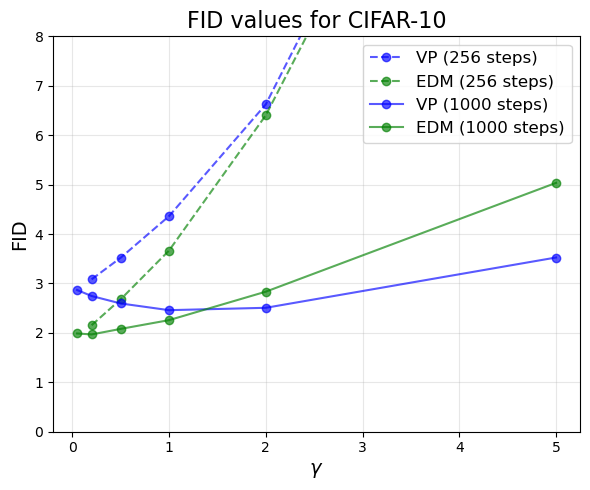

In [14]:
# Single list holding everything needed for plotting/comparison
all_fid_curves = []
for p in fid_paths:
    ode_fid, gammas, sde_fids = parse_fid_file(p)
    all_fid_curves.append(
        {
            "epoch": extract_epoch_from_path(p),
            "path": p,
            "ode_fid": ode_fid,
            "gammas": gammas,
            "sde_fids": sde_fids,
        }
    )

all_fid_curves.sort(key=lambda d: d["epoch"])

# Convenience arrays/lists
epochs = np.array([d["epoch"] for d in all_fid_curves], dtype=int)
gamma_values = all_fid_curves[0]["gammas"]
fid_curves = [d["sde_fids"] for d in all_fid_curves]
ode_fids = np.array([d["ode_fid"] for d in all_fid_curves], dtype=float)

plt.figure(figsize=(6, 5))
for idx, d in enumerate(all_fid_curves):
    if labels is not None:
        label = labels[idx]
    else:
        label = f'model {idx + 1}'
    if mode == "cifar10":
        color = colors[idx % 2]
        linestyle = "--" if idx < 2 else "-"
    else:
        color = colors[idx]
        linestyle = "-"
    plt.plot(
        d["gammas"],
        d["sde_fids"],
        marker="o",
        label=label,
        color=color,
        linestyle=linestyle,
    )
plt.xlabel("$\gamma$", fontsize=14)
plt.ylabel("FID", fontsize=14)
# intermediate scale between log and linear
if mode == "perturbed_prior":
    plt.title("FID values, perturbed prior, model 3", fontsize=16)
    plt.xscale("log")
    plt.yscale("log")
elif mode == "default_prior":
    plt.title("FID values for MNIST", fontsize=16)
    plt.xscale("log")
    plt.yscale("log")
elif mode == "cifar10":
    plt.title("FID values for CIFAR-10", fontsize=16)
    plt.ylim(0, 8)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## DSM error across time

In [20]:
# Load MNIST datasets
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
val_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# print dataset sizes
print(f"train_dataset size: {len(train_dataset)}") 
print(f"val_dataset size: {len(val_dataset)}")

# print dataset shapes
print(f"train_dataset[0][0].shape: {train_dataset[0][0].shape}")
print(f"val_dataset[0][0].shape: {val_dataset[0][0].shape}")

train_dataset size: 60000
val_dataset size: 10000
train_dataset[0][0].shape: torch.Size([1, 28, 28])
val_dataset[0][0].shape: torch.Size([1, 28, 28])


In [21]:
# Define model
model_channels = 128
modelconfig = diffsci.models.PUNetGConfig(model_channels=model_channels)
model = diffsci.models.PUNetG(modelconfig)
moduleconfig = diffsci.models.KarrasModuleConfig.from_edm()
module = diffsci.models.KarrasModule(model, moduleconfig, conditional=False)

In [25]:
# Load trained models

checkpoint_path = \
    "/home/ubuntu/repos/DiffSci/savedmodels/production/20260318-bps-mnist-128ch/checkpoints/model-epoch=009-val_loss=0.045098.ckpt"

module = diffsci.models.KarrasModule.load_from_checkpoint(checkpoint_path, model=model, config=moduleconfig, conditional=False)
module = module.to("cuda")

checkpoint_path2 = \
    "/home/ubuntu/repos/DiffSci/savedmodels/production/20260318-bps-mnist-128ch/checkpoints/model-epoch=019-val_loss=0.044191.ckpt"

module2 = diffsci.models.KarrasModule.load_from_checkpoint(checkpoint_path2, model=model, config=moduleconfig, conditional=False)
module2 = module2.to("cuda")

checkpoint_path3 = \
    "/home/ubuntu/repos/DiffSci/savedmodels/production/20260318-bps-mnist-128ch/checkpoints/model-epoch=039-val_loss=0.042329.ckpt"

module3 = diffsci.models.KarrasModule.load_from_checkpoint(checkpoint_path3, model=model, config=moduleconfig, conditional=False)
module3 = module3.to("cuda")

In [26]:
from torch.utils.data import DataLoader

n_samples = 2000
batch_size = 64
timesteps = 200

dsm_losses = []
for module in [module, module2, module3]:
    module.eval()
    device = module.device

    # Build validation tensor the same way as training (uses transform=ToTensor)
    val_x = torch.stack([val_dataset[i][0] for i in range(n_samples)], dim=0)  # [N,1,28,28], float in [0,1]
    val_loader = DataLoader(val_x, batch_size=batch_size, shuffle=False)

    # generate noise for each data batch
    noise_list = []
    for xb in val_loader:
        noise_list.append(torch.randn_like(xb))
    noise_list = torch.cat(noise_list, dim=0)
    noise_list = noise_list.to(device)

    time = moduleconfig.noisescheduler.create_steps(timesteps)

    dsm_loss = []
    with torch.no_grad():
        for t in time:
            total_loss = 0.0
            total_count = 0
            count = 0

            for xb in val_loader:
                xb = xb.to(device)

                # sigma must be per-sample: shape [batch]
                sigma_scalar = moduleconfig.noisescheduler.scheduler_fns.noise_fn(t)
                scale = moduleconfig.noisescheduler.scheduler_fns.scaling_fn(t)
                if not torch.is_tensor(sigma_scalar):
                    sigma_scalar = torch.tensor(sigma_scalar, device=device, dtype=xb.dtype)
                else:
                    sigma_scalar = sigma_scalar.to(device=device, dtype=xb.dtype)

                sigma = torch.full((xb.shape[0],), sigma_scalar.item(), device=device, dtype=xb.dtype)
                xb_noised = xb + noise_list[count] * sigma_scalar
                count += 1
                denoiser, _ = module.get_denoiser(xb_noised/scale, sigma)
                loss = torch.mean((denoiser - xb)**2)
                loss = loss/ sigma_scalar**4
                # loss = module.loss_fn(xb, sigma)  # scalar mean over this batch
                total_loss += loss.item() * xb.shape[0]
                total_count += xb.shape[0]

            dsm_loss.append(total_loss / total_count)
    dsm_losses.append(dsm_loss)

In [30]:
dsm_losses_normalized = [[dsm_losses[0][i] - dsm_losses[2][i] for i in range(timesteps)],
                        [dsm_losses[1][i] - dsm_losses[2][i] for i in range(timesteps)]]

# dm_losses_normalized = [[dsm_losses[0][i]-dsm_losses[2][i] for i in range(timesteps)],
#                         [dsm_losses[1][i]-dsm_losses[2][i] for i in range(timesteps)],
#                         [0 for i in range(timesteps)]]

# relative difference (true normalization)
eps = 1e-12
dsm_rel = [
    [(dsm_losses[0][i] - dsm_losses[2][i]) / (abs(dsm_losses[2][i]) + eps) for i in range(timesteps)],
    [(dsm_losses[1][i] - dsm_losses[2][i]) / (abs(dsm_losses[2][i]) + eps) for i in range(timesteps)],
]
dsm_losses_normalized = dsm_rel

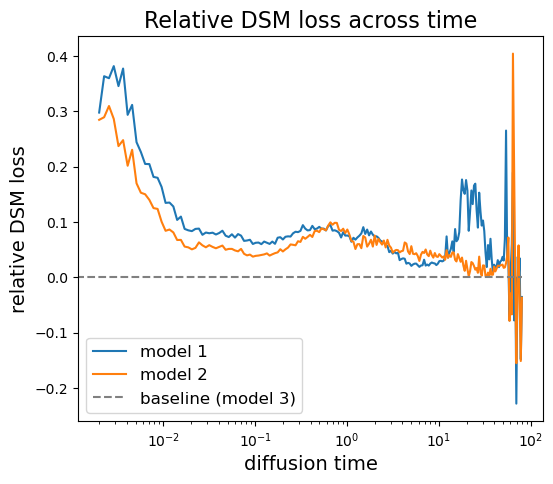

In [31]:
# plot in normal and log scale
both_scales = False

if both_scales:
    fig, axs = plt.subplots(1, 2, figsize=(12,5))
    for ax in axs.flatten():
        # ax.plot(time.cpu().numpy() if torch.is_tensor(time) else time, dsm_losses[0], label="model 1")
        # ax.plot(time.cpu().numpy() if torch.is_tensor(time) else time, dsm_losses[1], label="model 2")
        # ax.plot(time.cpu().numpy() if torch.is_tensor(time) else time, dsm_losses[2], label="model 3")
        ax.plot(time.cpu().numpy() if torch.is_tensor(time) else time, dsm_losses_normalized[0], label="model 1")
        ax.plot(time.cpu().numpy() if torch.is_tensor(time) else time, dsm_losses_normalized[1], label="model 2")
        ax.hlines(0, 0, 80, color="grey", linestyle="--", label="Baseline (model 3)")
        ax.set_xlabel("diffusion time")
        ax.legend()

    axs[0].set_ylabel("Average DSM Loss")
    axs[0].set_title("DSM Loss across time")
    axs[1].set_title("DSM Loss across time (log scale)")
    axs[1].set_xscale("log")
    plt.show()

else:
    fig, ax = plt.subplots(figsize=(6,5))
    ax.plot(time.cpu().numpy() if torch.is_tensor(time) else time, dsm_losses_normalized[0], label="model 1")
    ax.plot(time.cpu().numpy() if torch.is_tensor(time) else time, dsm_losses_normalized[1], label="model 2")
    ax.hlines(0, 0, 80, color="grey", linestyle="--", label="baseline (model 3)")
    ax.set_xlabel("diffusion time", fontsize=14)
    ax.set_xscale("log")
    # ax.set_yscale("log")
    ax.legend(fontsize=12)
    ax.set_ylabel("relative DSM loss", fontsize=14)
    ax.set_title("Relative DSM loss across time", fontsize=16)
    plt.show()


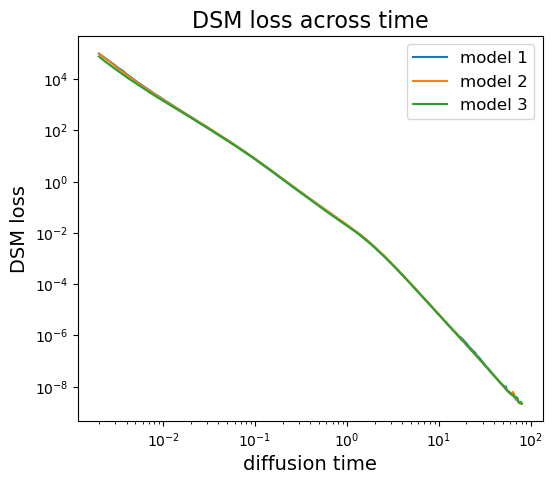

In [32]:
# plot in normal and log scale
both_scales = False

if both_scales:
    fig, axs = plt.subplots(1, 2, figsize=(12,5))
    for ax in axs.flatten():
        ax.plot(time.cpu().numpy() if torch.is_tensor(time) else time, dsm_losses[0], label="model 1")
        ax.plot(time.cpu().numpy() if torch.is_tensor(time) else time, dsm_losses[1], label="model 2")
        ax.plot(time.cpu().numpy() if torch.is_tensor(time) else time, dsm_losses[2], label="model 3")
        # plt.scatter(time.cpu().numpy() if torch.is_tensor(time) else time, dm_losses_normalized[1], label="Epoch 39")
        # ax.hlines(0, 0, 80, color="grey", linestyle="--", label="Baseline (Epoch 19)")
        # ax.plot(time.cpu().numpy() if torch.is_tensor(time) else time, dm_losses_normalized[2], label="Epoch 39")
        ax.set_xlabel("diffusion time")
        ax.legend()

    axs[0].set_ylabel("Average DSM Loss")
    axs[0].set_title("DSM Loss across time")
    axs[1].set_title("DSM Loss across time (log scale)")
    axs[1].set_xscale("log")
    plt.show()

else:
    fig, ax = plt.subplots(figsize=(6,5))
    ax.plot(time.cpu().numpy() if torch.is_tensor(time) else time, dsm_losses[0], label="model 1")
    ax.plot(time.cpu().numpy() if torch.is_tensor(time) else time, dsm_losses[1], label="model 2")
    ax.plot(time.cpu().numpy() if torch.is_tensor(time) else time, dsm_losses[2], label="model 3")
    ax.set_xlabel("diffusion time", fontsize=14)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend(fontsize=12)
    ax.set_ylabel("DSM loss", fontsize=14)
    ax.set_title("DSM loss across time", fontsize=16)
    plt.show()


## Plot images


In [14]:
from diffsci.models.karras.integrators import EulerIntegrator, EulerMaruyamaIntegrator

In [8]:
# module.config.noisescheduler.maximum_scale = 160

In [ ]:
# Collect real samples from validation set
n_samples = 20

# Create a reproducible random permutation of indices
all_indices = np.random.permutation(len(val_dataset))
selected_indices = all_indices[:n_samples]

real_samples = []
for i in selected_indices:
    img, _ = val_dataset[i]
    real_samples.append(img.numpy())

real_samples = np.array(real_samples)  # Shape: [n_samples, 1, H, W]
print(f"Real samples shape: {real_samples.shape}")

# Collect generated samples
image_size = 28
ode_integrator = EulerIntegrator()
sde_integrator = EulerMaruyamaIntegrator()
generated_samples_ode = module.sample(nsamples=n_samples, shape=[1, image_size, image_size],
                                      nsteps=200, integrator=ode_integrator)
generated_samples_ode = generated_samples_ode.detach().cpu().numpy()
print(f"Generated ODE samples shape: {generated_samples_ode.shape}")

# Generate SDE samples
gamma_list = [0.2, 1, 2, 5, 10]
sde_list = []
for gamma in gamma_list:
    module.config.noisescheduler.langevin_const = gamma
    generated_samples_sde = module.sample(nsamples=n_samples, shape=[1, image_size, image_size],
                                      nsteps=200, integrator=sde_integrator)
    generated_samples_sde = generated_samples_sde.detach().cpu().numpy()
    sde_list.append((gamma, generated_samples_sde))
    print(f"Generated SDE samples shape: {generated_samples_sde.shape}")


Real samples shape: (20, 1, 28, 28)
Generated ODE samples shape: (20, 1, 28, 28)
Generated SDE samples shape: (20, 1, 28, 28)
Generated SDE samples shape: (20, 1, 28, 28)
Generated SDE samples shape: (20, 1, 28, 28)
Generated SDE samples shape: (20, 1, 28, 28)
Generated SDE samples shape: (20, 1, 28, 28)


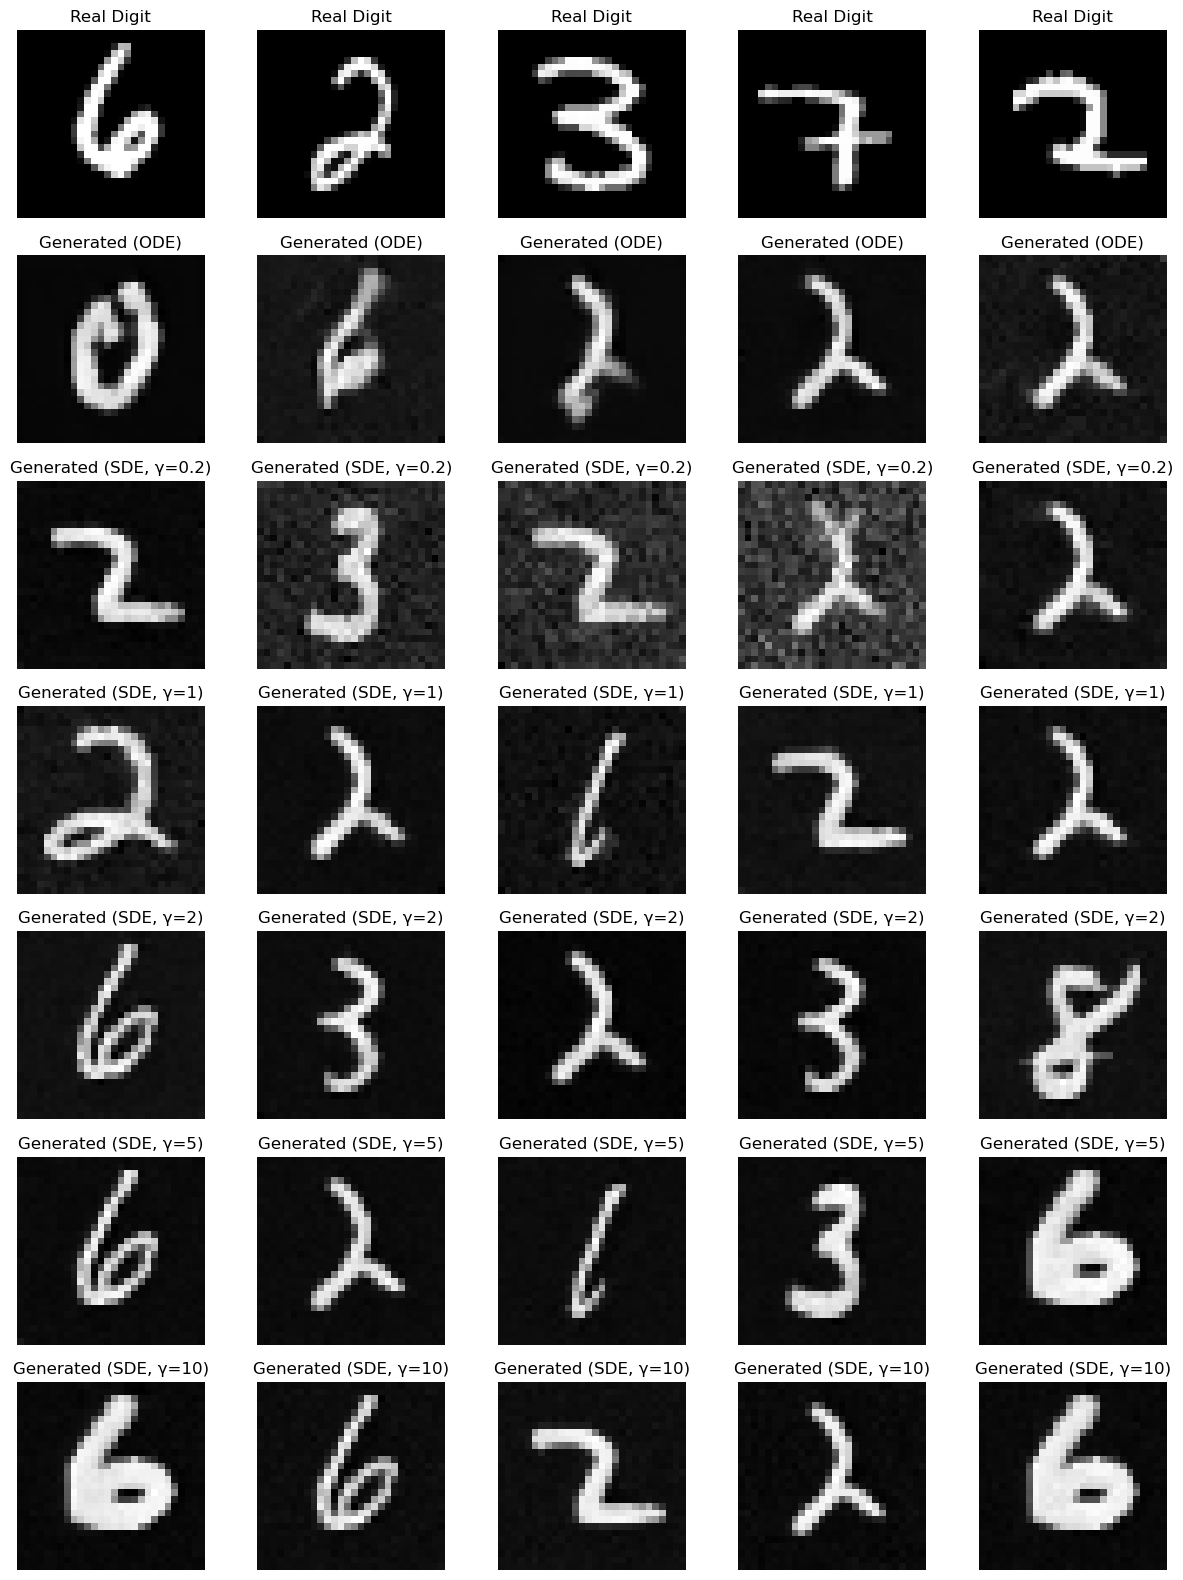

In [10]:
# Plot example images
n_examples = 5
fig, axes = plt.subplots(2+len(sde_list), n_examples, figsize=(15, 20))
for i in range(n_examples):
    axes[0, i].imshow(real_samples[i][0], cmap='gray')
    axes[0, i].set_title(f"Real Digit")
    axes[0, i].axis('off')
    
    axes[1, i].imshow(generated_samples_ode[i][0], cmap='gray')
    axes[1, i].set_title("Generated (ODE)")
    axes[1, i].axis('off')

    counter = 2
    for gamma, gen_sde_samples in sde_list:
        axes[counter, i].imshow(gen_sde_samples[i][0], cmap='gray')
        axes[counter, i].set_title(f"Generated (SDE, γ={gamma})")
        axes[counter, i].axis('off')
        counter += 1